### Citation: To help me create code, debug, and enhance the overall correctness and outcomes of my projects, I employed AI models.

## Importing libraries
#### Configuring the computer and importing every library

In [ ]:
import os
import math
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#print(f"Device: {device}")

In [ ]:
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True

#### Data Loading & Preprocessing
###### using augmentation transformations for training and normalizing for testing after loading the MNIST dataset.

In [ ]:
# Use random rotation and affine shifts to improve generality.
train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Simply normalizing test data without any augmentation
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


# Loading MNIST Dataset
train_dataset = torchvision.datasets.MNIST('./data', train=True,  download=True, transform=train_transform)
test_dataset  = torchvision.datasets.MNIST('./data', train=False, download=True, transform=test_transform)

# Raw pixel data without normalization for visualization
raw_data = train_dataset.data

# Shuffle training data using a batch size of 128 for each epoch.
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True,  pin_memory=True)
testloader  = torch.utils.data.DataLoader(test_dataset,  batch_size=128, shuffle=False, pin_memory=True)

#### Visualizing Sample MNIST Images
##### To verify that the dataset loaded well, a 4x4 grid of raw training images is displayed.

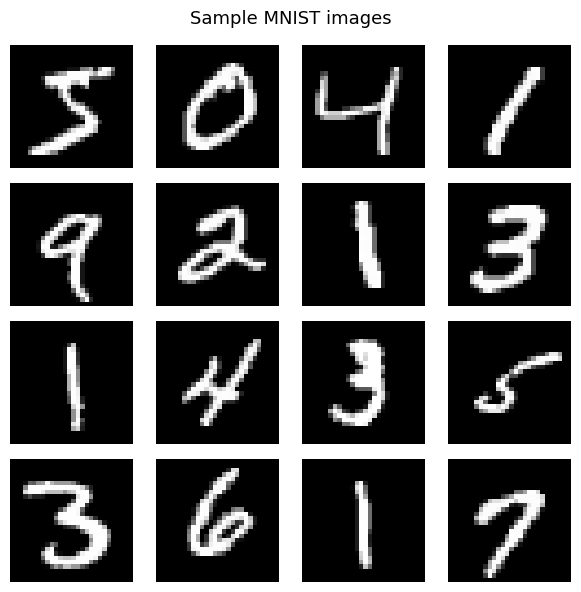

In [ ]:
# Plotting raw MNIST data in a 4x4 grid
fig, ax = plt.subplots(4, 4, figsize=(6, 6))

for i in range(4):
    for j in range(4):
        ax[i][j].imshow(raw_data[4*i+j], cmap='gray')
        ax[i][j].axis('off')

plt.suptitle('Sample MNIST images', fontsize=13)
plt.tight_layout()
plt.show()

####  Model Architecture

In [ ]:
# LeNet-5 CNN Model
# For improved accuracy, CNN uses three convolution layers, Dropout, and BatchNorm.
# Conv1(32) → BN → Pool → Conv2(64) → BN → Pool → Conv3(128) → BN → FC(256) → FC(10)
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()

        # Convolutional Layers
        self.conv1 = nn.Conv2d(1,  32, kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        # Pooling, Activation, Flatten layer
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU()
        self.flat  = nn.Flatten()

        # Fully Connected Layers
        self.fc1   = nn.Linear(128 * 5 * 5, 256)
        self.bn_fc = nn.BatchNorm1d(256)
        self.drop  = nn.Dropout(0.5)
        self.fc2   = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))   # 28→14
        x = self.pool(self.relu(self.bn2(self.conv2(x))))   # 14→5
        x = self.relu(self.bn3(self.conv3(x)))              # 5×5
        x = self.flat(x)
        x = self.drop(self.relu(self.bn_fc(self.fc1(x))))
        return self.fc2(x)

In [ ]:
# Model Summary
# Layer per layer, print the LeNet-5 output forms and parameter count.
!pip install torchsummary -q
from torchsummary import summary
summary(LeNet5().to(device), input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             832
       BatchNorm2d-2           [-1, 32, 28, 28]              64
              ReLU-3           [-1, 32, 28, 28]               0
         MaxPool2d-4           [-1, 32, 14, 14]               0
            Conv2d-5           [-1, 64, 10, 10]          51,264
       BatchNorm2d-6           [-1, 64, 10, 10]             128
              ReLU-7           [-1, 64, 10, 10]               0
         MaxPool2d-8             [-1, 64, 5, 5]               0
            Conv2d-9            [-1, 128, 5, 5]          73,856
      BatchNorm2d-10            [-1, 128, 5, 5]             256
             ReLU-11            [-1, 128, 5, 5]               0
          Flatten-12                 [-1, 3200]               0
           Linear-13                  [-1, 256]         819,456
      BatchNorm1d-14                  [

#### Training Utilities & curves
##### defining the curve plotting function and training loop function that are utilized in every experiment.

In [ ]:
# Trains any model for n_epochs, returns history, and monitors accuracy and loss.
def train_model(model, trainloader, testloader, device, n_epochs=20, lr=1e-3, weight_decay=1e-4):
    model = model.to(device)

    # The optimizer is Adam with L2 regularization.
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Loss Function
    loss_fn   = nn.CrossEntropyLoss()

    #LR Scheduler: eta_min via cosine decay from lr
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-5)

    train_accs, test_accs, train_losses = [], [], []

    for epoch in range(n_epochs):
        # Training phase
        model.train()
        correct, total, epoch_loss = 0, 0, 0.0
        for X_batch, y_batch in trainloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss   = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            correct    += (torch.argmax(y_pred, 1) == y_batch).sum().item()
            total      += len(y_batch)

        train_losses.append(epoch_loss / len(trainloader))
        train_accs.append(correct / total)

        #Evaluation phase
        model.eval()
        acc, count = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in testloader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                acc   += (torch.argmax(model(X_batch), 1) == y_batch).sum().item()
                count += len(y_batch)

        test_accs.append(acc / count)
        scheduler.step()
        print(f"Epoch {epoch+1:>2}/{n_epochs}  loss: {train_losses[-1]:.4f}  "
              f"train: {train_accs[-1]*100:.2f}%  test: {test_accs[-1]*100:.2f}%")

    return train_accs, test_accs, train_losses

In [ ]:
# Evaluation phase
# shows train/test accuracy and training loss side by side over epochs.
def plot_curves(train_accs, test_accs, train_losses, title_prefix, fig_path=None, target_line=None):
    epochs = range(1, len(train_accs) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy plot
    axes[0].plot(epochs, [a*100 for a in train_accs], label='Train', marker='o', markersize=3)
    axes[0].plot(epochs, [a*100 for a in test_accs],  label='Test',  marker='o', markersize=3)
    if target_line:
        axes[0].axhline(target_line, color='red', linestyle='--', linewidth=1, label=f'{target_line}% target')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_title(f'{title_prefix} – Accuracy over epochs')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Loss plot
    axes[1].plot(epochs, train_losses, label='Train loss', marker='o', markersize=3, color='tab:orange')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].set_title(f'{title_prefix} – Training loss over epochs')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if fig_path:
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {fig_path}')
    plt.show()

## Visualization

#### Learning Rate Schedule Visualization.

##### illustrating how the cosine annealing scheduler reduces the learning rate over 20 epochs.

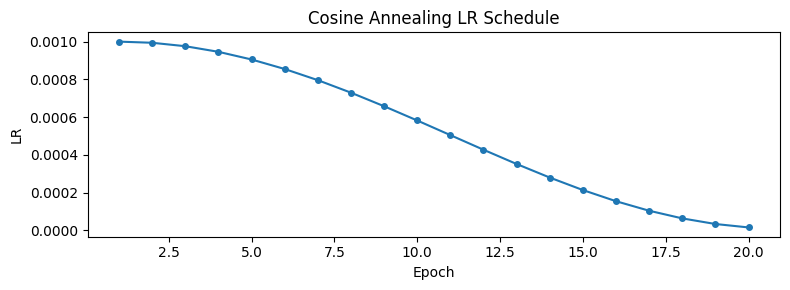

In [ ]:
# Cosine Annealing LR Schedule Plot
# uses a cosine curve to show how the learning rate decreases from 1e-3 to 1e-5.
lrs = [1e-5 + 0.5*(1e-3 - 1e-5)*(1 + math.cos(math.pi * e / 20)) for e in range(20)]
plt.figure(figsize=(8, 3))
plt.plot(range(1, 21), lrs, marker='o', markersize=4)
plt.xlabel('Epoch'); plt.ylabel('LR')
plt.title('Cosine Annealing LR Schedule')
plt.tight_layout()
plt.show()

#### Training Loop

##### After instantiating LeNet-5 and training for 20 epochs, the accuracy and loss curves are plotted.

In [ ]:
print("=" * 40)
print(" Training LeNet-5 (20 epochs)")
print("=" * 40)

lenet_model = LeNet5()
# Run training.
#Accuracy and loss history are returned.
train_accs, test_accs, train_losses = train_model(
    lenet_model, trainloader, testloader, device, n_epochs=20
)
print(f"\nLeNet-5 final test accuracy: {test_accs[-1]*100:.2f}%")

 Training LeNet-5 (20 epochs)
Epoch  1/20  loss: 0.1874  train: 94.81%  test: 98.88%
Epoch  2/20  loss: 0.0787  train: 97.64%  test: 99.10%
Epoch  3/20  loss: 0.0638  train: 98.07%  test: 99.21%
Epoch  4/20  loss: 0.0563  train: 98.25%  test: 99.17%
Epoch  5/20  loss: 0.0495  train: 98.47%  test: 99.35%
Epoch  6/20  loss: 0.0461  train: 98.63%  test: 99.48%
Epoch  7/20  loss: 0.0440  train: 98.69%  test: 99.36%
Epoch  8/20  loss: 0.0382  train: 98.83%  test: 99.46%
Epoch  9/20  loss: 0.0380  train: 98.85%  test: 99.44%
Epoch 10/20  loss: 0.0337  train: 98.95%  test: 99.52%
Epoch 11/20  loss: 0.0325  train: 98.95%  test: 99.52%
Epoch 12/20  loss: 0.0283  train: 99.10%  test: 99.60%
Epoch 13/20  loss: 0.0283  train: 99.15%  test: 99.59%
Epoch 14/20  loss: 0.0241  train: 99.28%  test: 99.56%
Epoch 15/20  loss: 0.0226  train: 99.35%  test: 99.61%
Epoch 16/20  loss: 0.0205  train: 99.39%  test: 99.61%
Epoch 17/20  loss: 0.0189  train: 99.44%  test: 99.67%
Epoch 18/20  loss: 0.0183  train: 9

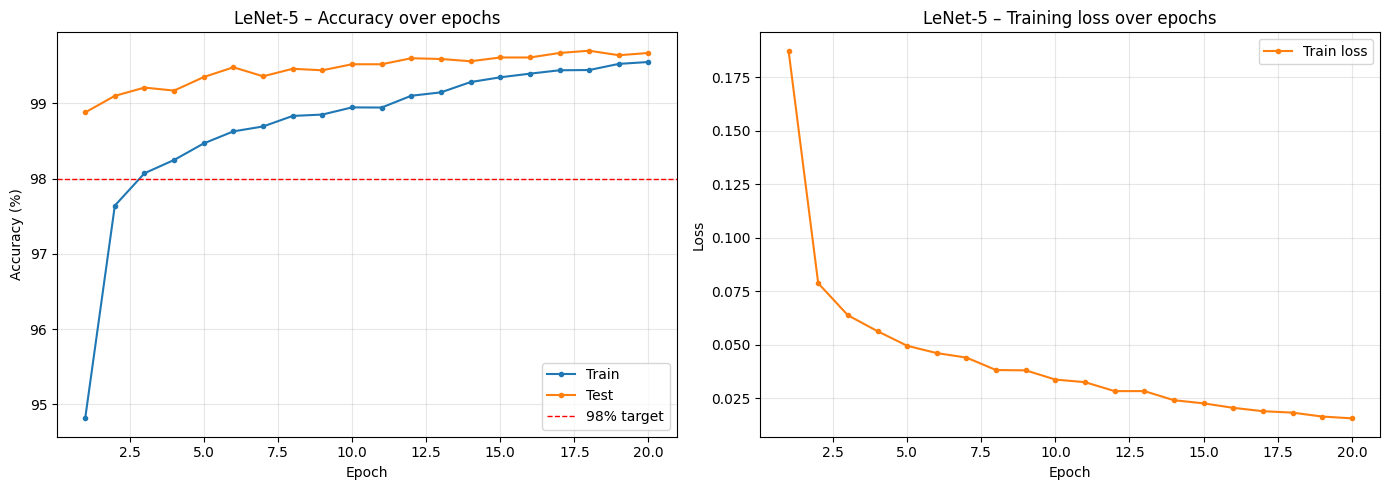

In [ ]:
# Plotting accuracy and loss curves
plot_curves(train_accs, test_accs, train_losses, title_prefix='LeNet-5', target_line=98)

####  Evaluation & Results

##### using the test set to analyze the trained LeNet-5 and get thorough performance metrics.

In [ ]:
lenet_model.eval()
all_preds, all_targets = [], []
correct, total = 0, 0

with torch.no_grad():
    for X_batch, y_batch in testloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs   = lenet_model(X_batch)
        predicted = torch.argmax(outputs, 1)
        correct  += (predicted == y_batch).sum().item()
        total    += len(y_batch)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())

print(f"Final test accuracy: {correct/total*100:.2f}%")
lenet_model.train()

Final test accuracy: 99.67%


LeNet5(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flat): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3200, out_features=256, bias=True)
  (bn_fc): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

In [ ]:
# Per-Class Classification Report
# Showing the recall, precision, and F1-score for each digit class (0–9).
print('Per-class performance report:')
print(classification_report(all_targets, all_preds, target_names=[str(i) for i in range(10)]))

Per-class performance report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       1.00      1.00      1.00      1010
           4       0.99      0.99      0.99       982
           5       1.00      0.99      1.00       892
           6       1.00      1.00      1.00       958
           7       1.00      1.00      1.00      1028
           8       1.00      1.00      1.00       974
           9       0.99      0.99      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



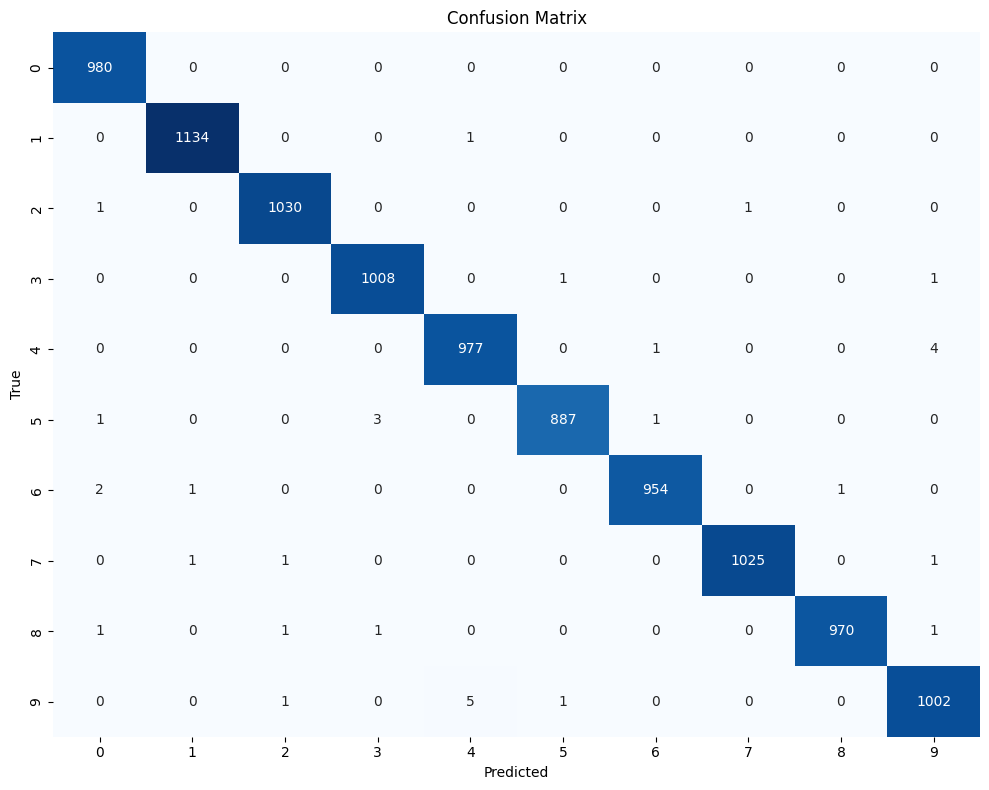

In [ ]:
# Confusion Matrix
# Heatmap showing the replaceable numbers
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

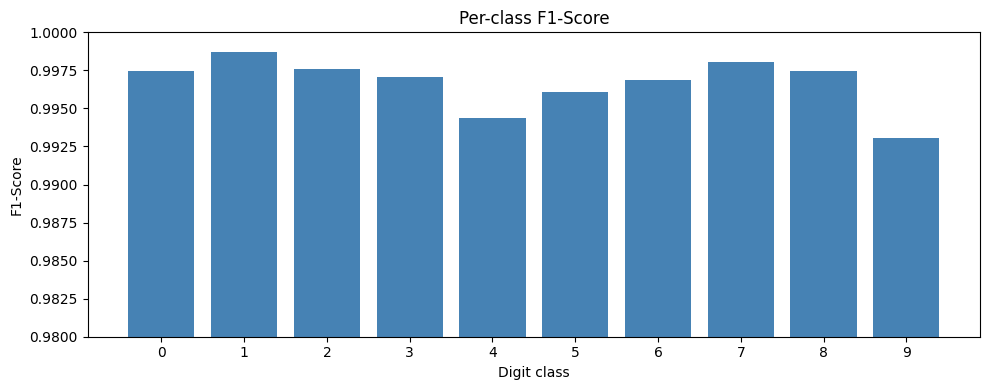

In [ ]:
# Per-Class F1-Score Bar Chart
# Demonstrates how well the model handles each specific digit.
f1_per_class = f1_score(all_targets, all_preds, average=None)
plt.figure(figsize=(10, 4))
plt.bar(range(10), f1_per_class, color='steelblue')
plt.xticks(range(10)); plt.ylim(0.98, 1.0)
plt.xlabel('Digit class'); plt.ylabel('F1-Score')
plt.title('Per-class F1-Score')
plt.tight_layout()
plt.show()

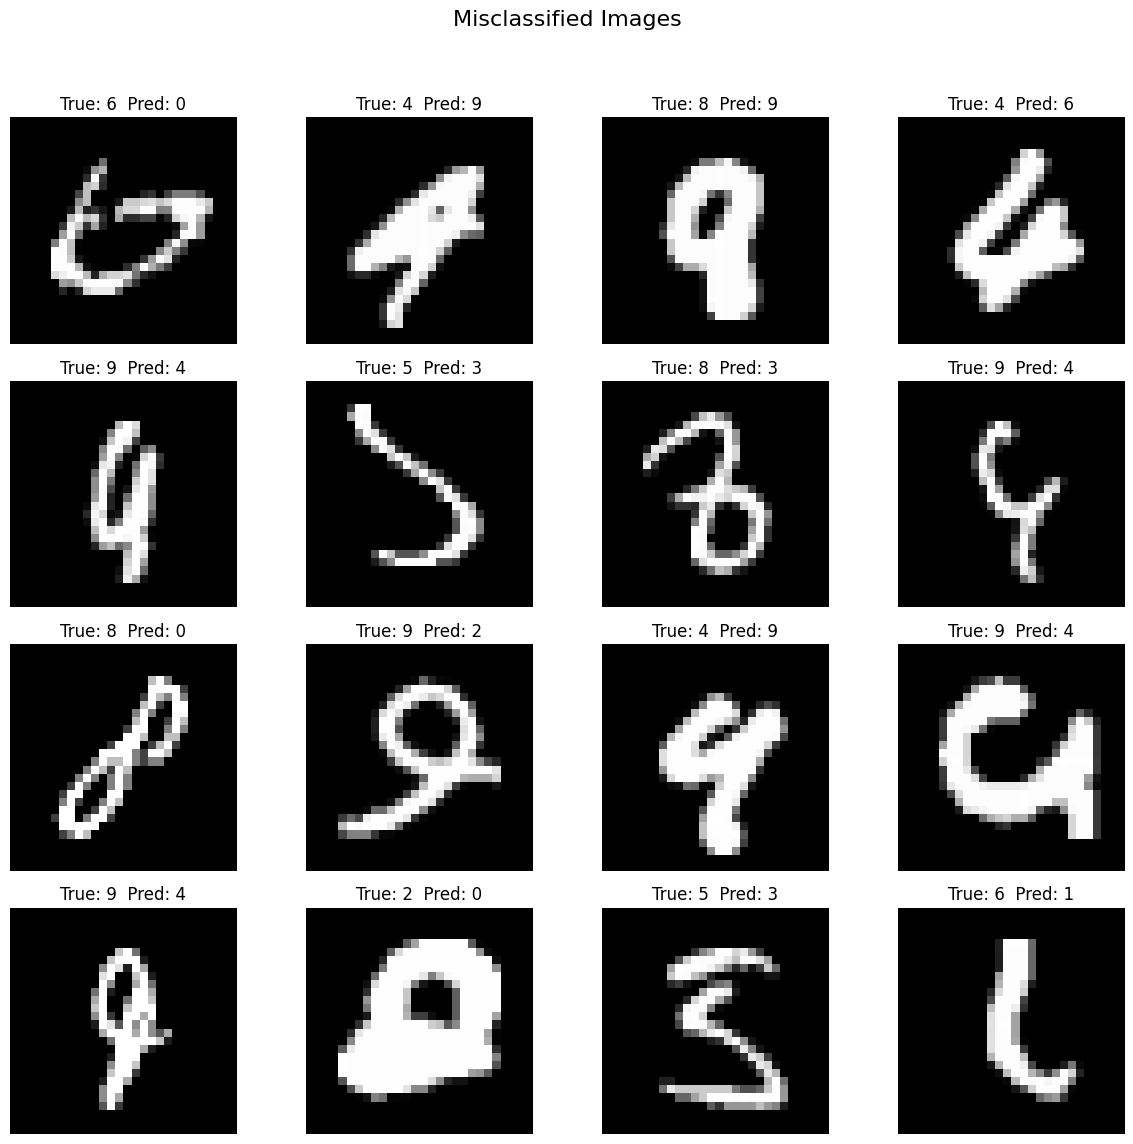

In [ ]:
# Misclassified Samples
# To demonstrate where the model falters, display the first 16 inaccurate photos.

misclassified = (torch.tensor(all_preds) != torch.tensor(all_targets)).nonzero(as_tuple=True)[0]

plt.figure(figsize=(12, 12))
for i, idx in enumerate(misclassified[:16]):
    plt.subplot(4, 4, i+1)
    plt.imshow(test_dataset.data[idx], cmap='gray')
    plt.title(f"True: {all_targets[idx]}  Pred: {all_preds[idx]}")
    plt.axis('off')
plt.suptitle('Misclassified Images', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Ablation Study
#### Assessing the real accuracy impact of removing BatchNorm from the Enhanced LeNet-5
##### We retrain a model without any BatchNorm layers and compare it to the whole model to show the exact contribution of BatchNorm to accuracy and convergence speed.

In [ ]:
# LeNet-5 WITHOUT BatchNorm
# The whole model is identical, except all BatchNorm layers have been eliminated.
# This isolates BatchNorm's precise contribution to final accuracy.
class LeNet5_NoBatchNorm(nn.Module):
    def __init__(self):
        super().__init__()

        # Convolutional Layers with no BatchNorm
        self.conv1 = nn.Conv2d(1,  32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # Pooling, Activation, Flatten
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU()
        self.flat  = nn.Flatten()

        # Fully Connected Layers with no BatchNorm
        self.fc1   = nn.Linear(128 * 5 * 5, 256)
        self.drop  = nn.Dropout(0.5)
        self.fc2   = nn.Linear(256, 10)

    def forward(self, x):
        # Block 1 — Conv → ReLU → Pool with no BatchNorm
        # 28×28 → 14×14
        x = self.pool(self.relu(self.conv1(x)))

        # Block 2 — Conv → ReLU → Pool with no BatchNorm
        # 14×14 → 5×5
        x = self.pool(self.relu(self.conv2(x)))

        # Block 3 — Conv → ReLU with no BatchNorm
        # 5×5 → 5×5
        x = self.relu(self.conv3(x))


        x = self.flat(x)
        x = self.drop(self.relu(self.fc1(x)))      # no BN1d before ReLU
        return self.fc2(x)


In [ ]:
# No BatchNorm Model Training
# Use the same training settings for the whole model to provide a fair comparison:
# Adam, batch=128, lr=1e-3, weight_decay=1e-4, CosineAnnealingLR, 20 epochs
print("=" * 50)
print(" Training LeNet-5 without BatchNorm")
print("=" * 50)

ablation_model = LeNet5_NoBatchNorm()

ablation_train_accs, ablation_test_accs, ablation_train_losses = train_model(
    ablation_model, trainloader, testloader, device, n_epochs=20
)

print('\n')
print(f"final test accuracy : {ablation_test_accs[-1]*100:.2f}%")
print(f"final test accuracy: {test_accs[-1]*100:.2f}%")
print('\n')
print(f"Accuracy drop from removing BatchNorm  : {(test_accs[-1] - ablation_test_accs[-1])*100:.2f} percentage points")


 Training LeNet-5 without BatchNorm
Epoch  1/20  loss: 0.3064  train: 90.28%  test: 98.82%
Epoch  2/20  loss: 0.0993  train: 96.98%  test: 99.12%
Epoch  3/20  loss: 0.0740  train: 97.77%  test: 99.13%
Epoch  4/20  loss: 0.0639  train: 98.06%  test: 99.30%
Epoch  5/20  loss: 0.0567  train: 98.34%  test: 99.33%
Epoch  6/20  loss: 0.0524  train: 98.41%  test: 99.26%
Epoch  7/20  loss: 0.0449  train: 98.67%  test: 99.34%
Epoch  8/20  loss: 0.0428  train: 98.72%  test: 99.50%
Epoch  9/20  loss: 0.0398  train: 98.77%  test: 99.46%
Epoch 10/20  loss: 0.0338  train: 98.95%  test: 99.42%
Epoch 11/20  loss: 0.0313  train: 99.04%  test: 99.57%
Epoch 12/20  loss: 0.0299  train: 99.08%  test: 99.58%
Epoch 13/20  loss: 0.0261  train: 99.24%  test: 99.57%
Epoch 14/20  loss: 0.0248  train: 99.24%  test: 99.54%
Epoch 15/20  loss: 0.0221  train: 99.29%  test: 99.56%
Epoch 16/20  loss: 0.0207  train: 99.33%  test: 99.61%
Epoch 17/20  loss: 0.0182  train: 99.45%  test: 99.59%
Epoch 18/20  loss: 0.0170  tr

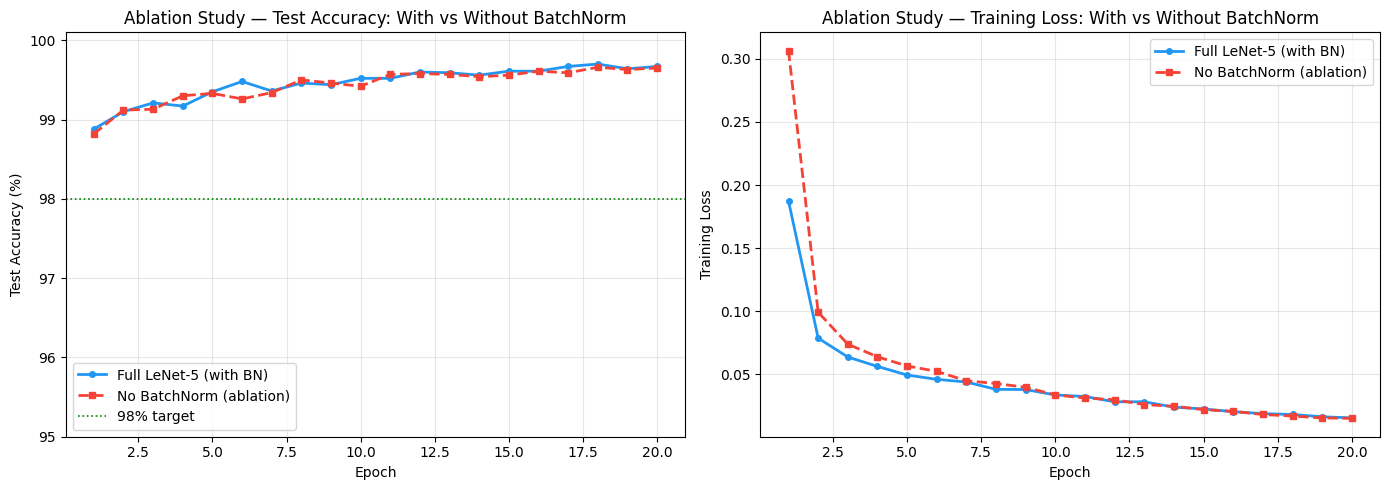

In [ ]:
# Comparison Plot
# A comparison is made between the full LeNet-5 and No-BatchNorm ablation models.
# Shows accuracy and loss curves to show how BatchNorm on the pace of convergence and the ultimate performance.

epochs = range(1, 21)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(epochs, [a*100 for a in test_accs],
             label='Full LeNet-5 (with BN)', marker='o', markersize=4, color='#2196F3', linewidth=2)
axes[0].plot(epochs, [a*100 for a in ablation_test_accs],
             label='No BatchNorm (ablation)', marker='s', markersize=4, color='#F44336', linewidth=2, linestyle='--')
axes[0].axhline(98, color='green', linestyle=':', linewidth=1.2, label='98% target')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Ablation Study — Test Accuracy: With vs Without BatchNorm')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(95, 100.1)

# Loss comparison
axes[1].plot(epochs, train_losses,
             label='Full LeNet-5 (with BN)', marker='o', markersize=4, color='#2196F3', linewidth=2)
axes[1].plot(epochs, ablation_train_losses,
             label='No BatchNorm (ablation)', marker='s', markersize=4, color='#F44336', linewidth=2, linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Training Loss')
axes[1].set_title('Ablation Study — Training Loss: With vs Without BatchNorm')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Results Table
# Creates an easy-to-read summary table that contrasts the two models based on key factors.

full_epoch1_acc   = test_accs[0]*100
ablation_epoch1_acc = ablation_test_accs[0]*100
full_best         = max(test_accs)*100
ablation_best     = max(ablation_test_accs)*100
full_final        = test_accs[-1]*100
ablation_final    = ablation_test_accs[-1]*100
full_train_gap = (train_accs[-1] - test_accs[-1]) * 100
drop   = (test_accs[-1] - ablation_test_accs[-1])*100

print("=" * 62)
print(f"{'ABLATION RESULTS':^62}")
print(f"{'Component Removed: BatchNorm (all layers)':^62}")
print("=" * 62)
print(f"{'Metric':<35} {'Full Model':>12} {'No BN':>12}")
print("-" * 62)
print(f"{'Epoch 1 Test Accuracy':<35} {full_epoch1_acc:>11.2f}% {ablation_epoch1_acc:>11.2f}%")
print(f"{'Best Test Accuracy (20 epochs)':<35} {full_best:>11.2f}% {ablation_best:>11.2f}%")
print(f"{'Final Test Accuracy (Epoch 20)':<35} {full_final:>11.2f}% {ablation_final:>11.2f}%")
print(f"{'Final Train Accuracy':<35} {train_accs[-1]*100:>11.2f}% {ablation_train_accs[-1]*100:>11.2f}%")
print("-" * 62)
print(f"{'Accuracy Drop (Final)':<35} {'—':>12} {-drop:>+11.2f}%")
print("=" * 62)
print()

                       ABLATION RESULTS                       
          Component Removed: BatchNorm (all layers)           
Metric                                Full Model        No BN
--------------------------------------------------------------
Epoch 1 Test Accuracy                     98.88%       98.82%
Best Test Accuracy (20 epochs)            99.70%       99.66%
Final Test Accuracy (Epoch 20)            99.67%       99.65%
Final Train Accuracy                      99.55%       99.52%
--------------------------------------------------------------
Accuracy Drop (Final)                          —       -0.02%

